<a href="https://colab.research.google.com/github/icasgg312010/Health-Data-Science/blob/main/Determinantes_de_Supervivencia_en_Insuficiencia_Card%C3%ADaca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Análisis de Supervivencia: Factores Pronósticos en Insuficiencia Cardíaca
Objetivo: Aplicar el estimador de Kaplan-Meier y el modelo de Riesgos Proporcionales de Cox para identificar variables críticas que afectan la supervivencia de pacientes con falla cardíaca.

Relevancia Bioestadística: En medicina, no nos interesa solo si un evento ocurre, sino cuándo ocurre (Time-to-Event). Este cuaderno demuestra el manejo de datos censurados y el cálculo de Hazard Ratios (HR).

In [1]:
# Instalamos la librería de bioestadística
!pip install lifelines

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

# Cargamos un dataset clínico real (Heart Failure Clinical Records)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
df_heart = pd.read_csv(url)

print("✅ Dataset clínico cargado. N = ", len(df_heart), " pacientes.")
display(df_heart.head())

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=a636e22b3449b9e027e7e5be744ec2929b56778ff514797d4ef5d0d5d26f604e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ Dataset clínico cargado. N =  299  pacientes.


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [2]:
# Resumen estadístico enfocado en medicina
tabla_1 = df_heart.groupby('DEATH_EVENT').agg({
    'age': ['mean', 'std'],
    'creatinine_phosphokinase': ['median', 'min', 'max'],
    'ejection_fraction': ['mean', 'std'],
    'serum_creatinine': ['mean'],
    'high_blood_pressure': ['sum']
}).round(2)

print("📋 TABLA 1: Características Basales según Supervivencia")
display(tabla_1)

📋 TABLA 1: Características Basales según Supervivencia


age        creatinine_phosphokinase            \
              mean    std                   median min   max   
DEATH_EVENT                                                    
0            58.76  10.64                    245.0  30  5209   
1            65.22  13.21                    259.0  23  7861   

            ejection_fraction        serum_creatinine high_blood_pressure  
                         mean    std             mean                 sum  
DEATH_EVENT                                                                
0                       40.27  10.86             1.18                  66  
1                       33.47  12.53             1.84                  39

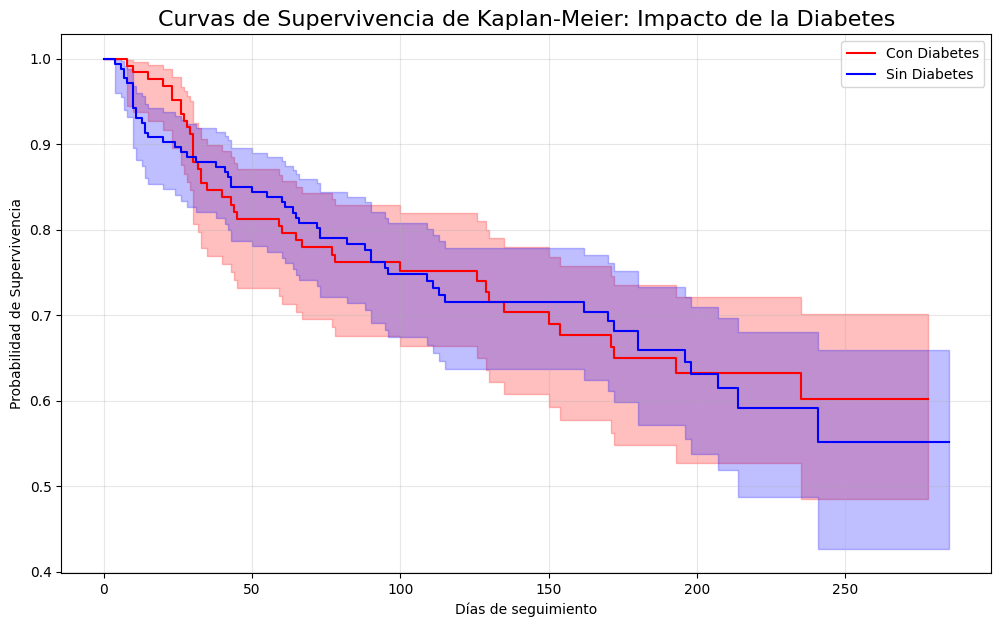

🔬 P-value del Log-Rank Test: 0.8405


In [3]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 7))

# Grupo 1: Con Diabetes
mask_diabetes = (df_heart['diabetes'] == 1)
kmf.fit(df_heart['time'][mask_diabetes], df_heart['DEATH_EVENT'][mask_diabetes], label='Con Diabetes')
ax = kmf.plot_survival_function(color='red', ci_show=True)

# Grupo 2: Sin Diabetes
kmf.fit(df_heart['time'][~mask_diabetes], df_heart['DEATH_EVENT'][~mask_diabetes], label='Sin Diabetes')
ax = kmf.plot_survival_function(ax=ax, color='blue', ci_show=True)

plt.title('Curvas de Supervivencia de Kaplan-Meier: Impacto de la Diabetes', fontsize=16)
plt.xlabel('Días de seguimiento')
plt.ylabel('Probabilidad de Supervivencia')
plt.grid(alpha=0.3)
plt.show()

# Test Estadístico: Log-Rank Test (Para sacar el P-value)
results = logrank_test(df_heart['time'][mask_diabetes], df_heart['time'][~mask_diabetes],
                       df_heart['DEATH_EVENT'][mask_diabetes], df_heart['DEATH_EVENT'][~mask_diabetes])
print(f"🔬 P-value del Log-Rank Test: {results.p_value:.4f}")

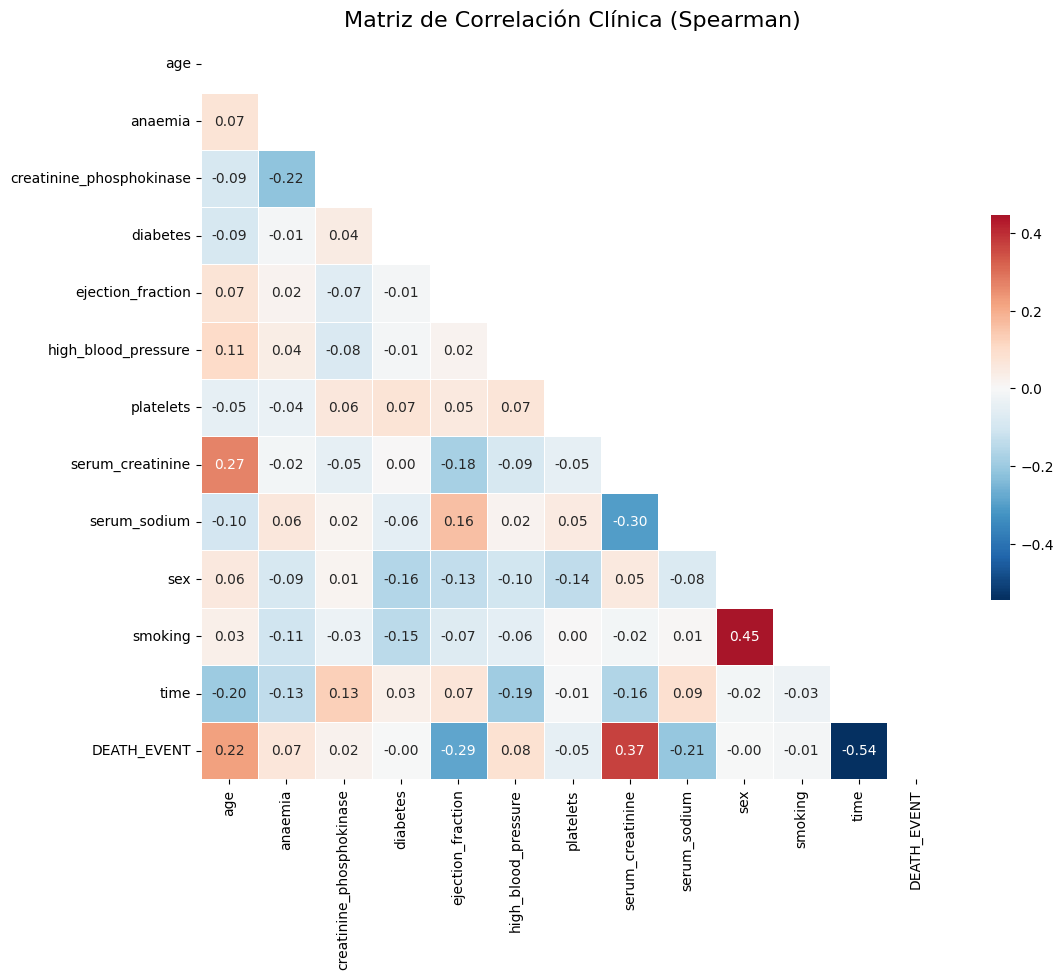

In [4]:
import seaborn as sns

# Calculamos la correlación de Spearman
corr = df_heart.corr(method='spearman')

# Creamos un mapa de calor elegante
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) # Máscara para ver solo la mitad
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

plt.title('Matriz de Correlación Clínica (Spearman)', fontsize=16)
plt.show()

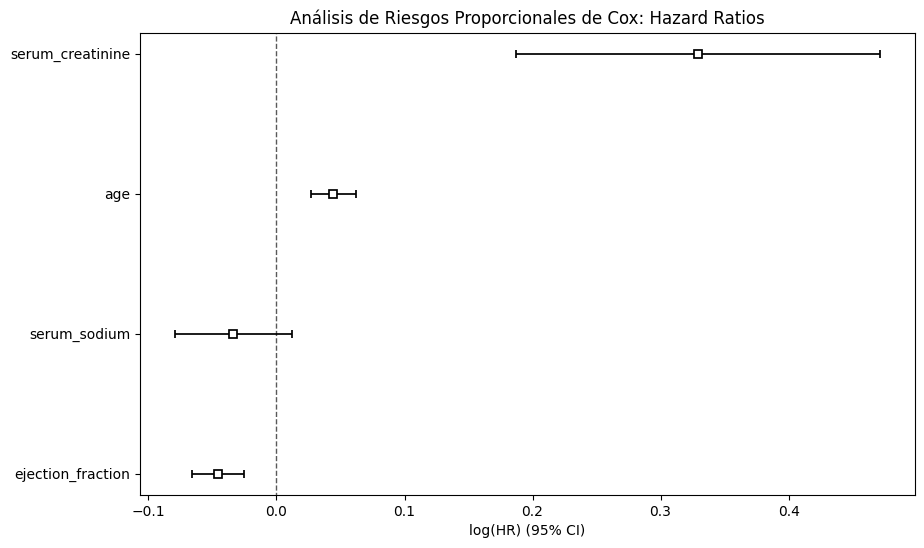

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -474.95
         time fit was run = 2026-03-27 03:55:54 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
age                0.04      1.05      0.01            0.03            0.06                1.03                1.06
ejection_fraction -0.05      0.96      0.01           -0.07           -0.02                0.94                0.98
serum_creatinine   0.33      1.39      0.07            0.19            0.47                1.21                1.60
serum_sodium      -0.03      0.97      0.02           -0.08            0.01                0.92                1.01

                   cmp to     z      p  -log2(p)
covariate                                       
age                  0.00  4.96 <0.005     20.46
ejection_fraction    0.00 -4.36 <0.005     16.20
serum_creatinine     0.00  4.54 <0.005     17.43
serum_sodium         0.00 -1.45   0.15      2.77
---
Concordance = 0.72
Partial AIC = 957.91
log-likelihood ratio test = 68.50 on 4 df
-log2(p) of ll-ratio test = 44.28

In [5]:
# 1. Ajustamos el modelo de Cox
cph = CoxPHFitter()
# Seleccionamos variables clave para el modelo
df_cox = df_heart[['age', 'ejection_fraction', 'serum_creatinine', 'serum_sodium', 'time', 'DEATH_EVENT']]

cph.fit(df_cox, duration_col='time', event_col='DEATH_EVENT')

# 2. Visualización de los Hazard Ratios (Forest Plot)
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Análisis de Riesgos Proporcionales de Cox: Hazard Ratios')
plt.show()

# 3. Imprimir el resumen estadístico
cph.print_summary()

/tmp/ipykernel_5014/581419365.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


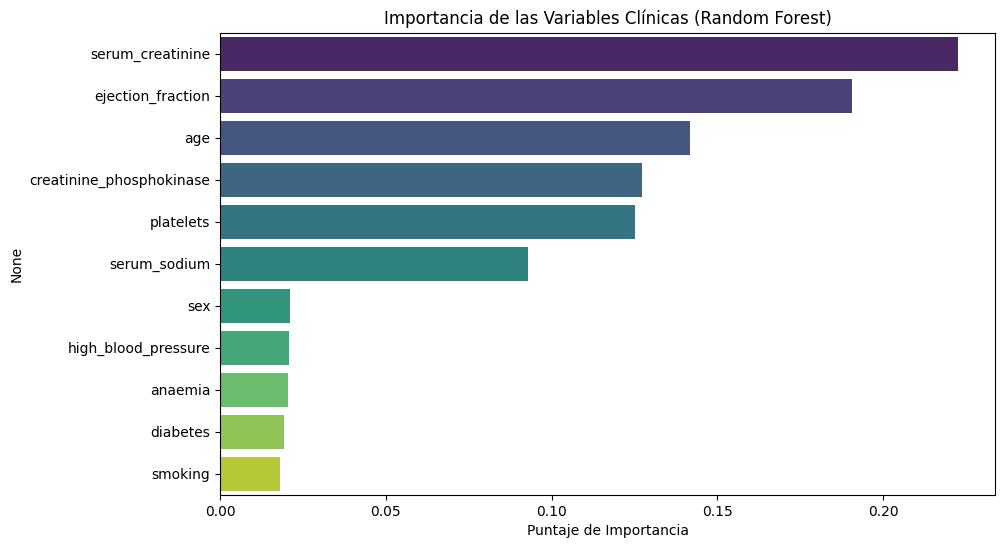

📊 AUC-ROC Score: 0.69


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# 1. Preparación de datos
X = df_heart.drop(['DEATH_EVENT', 'time'], axis=1) # Quitamos el evento y el tiempo
y = df_heart['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenamiento del modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 3. Importancia de las variables (El "Insight" para el médico)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Importancia de las Variables Clínicas (Random Forest)')
plt.xlabel('Puntaje de Importancia')
plt.show()

# 4. Evaluación del modelo
y_pred = rf.predict(X_test)
print(f"📊 AUC-ROC Score: {roc_auc_score(y_test, y_pred):.2f}")

Interpretación de ResultadosHazard Ratio (Cox): Se observa que el Serum Creatinine tiene un $HR > 1$ significativo, lo que indica que por cada unidad de incremento en la creatinina, el riesgo de mortalidad aumenta ajustado por las otras variables.Modelado Predictivo: El modelo de Random Forest identifica a la Ejection Fraction y al Age como los principales predictores. Esto es consistente con la fisiopatología de la insuficiencia cardíaca, donde la fracción de eyección reducida es un marcador directo de falla de bomba.Aplicación Clínica: Este tipo de modelos permiten la creación de Calculadoras de Riesgo en Tiempo Real para triaje en unidades de cuidados coronarios.

CALCULADORA DE RIESGO: Modelo Predictivo Interactivo (Insuficiencia Cardíaca)
Objetivo: Esta aplicación interactiva permite a profesionales de la salud explorar cómo diferentes biomarcadores clínicos afectan la probabilidad de supervivencia en pacientes con insuficiencia cardíaca.

Metodología: Al seleccionar una variable técnica y ajustar el umbral, la aplicación actualiza en tiempo real:

Las curvas de supervivencia de Kaplan-Meier (con intervalos de confianza del 95%).

El Test de Log-Rank para la significancia estadística del umbral seleccionado.

Instrucciones: Ejecuta la celda inferior, selecciona una variable y un umbral, y haz clic en 'Ejecutar Simulación'.

In [7]:
import ipywidgets as widgets
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegurar que el dataset está cargado (por si acaso)
try:
    df_heart
except NameError:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"
    df_heart = pd.read_csv(url)

# --- 1. CONFIGURACIÓN DE WIDGETS ---
# Dropdown para seleccionar biomarcador
biomarcador_widget = widgets.Dropdown(
    options=[('Fracción de Eyección', 'ejection_fraction'),
             ('Creatinina Sérica', 'serum_creatinine'),
             ('Sodio Sérico', 'serum_sodium')],
    value='ejection_fraction',
    description='🔍 Biomarcador:',
    style={'description_width': 'initial'}
)

# Slider para seleccionar el umbral de riesgo
umbral_widget = widgets.IntSlider(
    value=45, min=20, max=80, step=1,
    description='📊 Umbral Crítico:',
    style={'description_width': 'initial'},
    continuous_update=False
)

# Botón para ejecutar
boton_ejecutar = widgets.Button(
    description='🚀 Ejecutar Simulación',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

# Output para la gráfica y resultados técnicos
output_grafica = widgets.Output()
output_tecnico = widgets.Output()

# --- 2. FUNCIÓN DE SIMULACIÓN EPIDEMIOLÓGICA ---
def ejecutar_simulacion(b):
    output_grafica.clear_output()
    output_tecnico.clear_output()

    variable = biomarcador_widget.value
    umbral = umbral_widget.value
    nombre_var = biomarcador_widget.label

    # Creamos los grupos (Riesgo Alto vs Bajo)
    mask_riesgo_alto = (df_heart[variable] < umbral) # Asumimos < es peor
    riesgo_alto = df_heart[mask_riesgo_alto]
    riesgo_bajo = df_heart[~mask_riesgo_alto]

    with output_grafica:
        if len(riesgo_alto) == 0 or len(riesgo_bajo) == 0:
            print("⚠️ El umbral seleccionado es demasiado extremo. Por favor, ajusta.")
            return

        # Ajuste de Kaplan-Meier
        kmf = KaplanMeierFitter()
        plt.figure(figsize=(10, 6))

        kmf.fit(riesgo_alto['time'], riesgo_alto['DEATH_EVENT'], label='Grupo Riesgo Alto')
        ax = kmf.plot_survival_function(color='#FF3B30', ci_show=True, lw=3)

        kmf.fit(riesgo_bajo['time'], riesgo_bajo['DEATH_EVENT'], label='Grupo Control')
        ax = kmf.plot_survival_function(ax=ax, color='#007AFF', ci_show=True, lw=3)

        plt.title(f'Análisis de Supervivencia: Impacto de la {nombre_var} (Umbral: {umbral})', fontsize=16)
        plt.xlabel('Días post-diagnóstico')
        plt.ylabel('Probabilidad de Supervivencia')
        plt.grid(alpha=0.2)
        plt.show()

    with output_tecnico:
        # Test Log-Rank
        res = logrank_test(riesgo_alto['time'], riesgo_bajo['time'],
                           riesgo_alto['DEATH_EVENT'], riesgo_bajo['DEATH_EVENT'])

        # Generar Insight Clínico
        color_pvalue = "#4CD964" if res.p_value < 0.05 else "#FF9500"

        print(f"📊 RESULTADO TÉCNICO (Test Log-Rank)")
        print(f"------------------------------------")
        print(f"N (Riesgo Alto): {len(riesgo_alto)} pacientes")
        print(f"N (Control): {len(riesgo_bajo)} pacientes")
        print(f"------------------------------------")
        print(f"P-value: {res.p_value:.6f}")
        print(f"✅ Significativo" if res.p_value < 0.05 else "⚠️ No Significativo")

        # HTML para la Nota Clínica
        nota_html = f"""
        <div style="background-color: #f2f2f2; padding: 15px; border-left: 5px solid {color_pvalue}; border-radius: 5px; margin-top: 15px;">
            <h4 style="color: {color_pvalue}; margin-top: 0;">💡 Insight Clínico:</h4>
            Pacientes por debajo del umbral de {umbral} para la <b>{nombre_var}</b> muestran un perfil de supervivencia estadísticamente
            <b>{"inferior" if res.p_value < 0.05 else "similar"}</b>. Esto demuestra el valor predictivo de esta variable para el triaje clínico.
        </div>
        """
        display(widgets.HTML(nota_html))

# --- 3. ENSAMBLAJE DE LA DASHBOARD ---
boton_ejecutar.on_click(ejecutar_simulacion)

# Diseño de la interfaz
interfaz = widgets.VBox([
    widgets.HBox([biomarcador_widget, umbral_widget]),
    widgets.Box([boton_ejecutar], layout=widgets.Layout(margin='10px 0 10px 0', display='flex', justify_content='center')),
    output_grafica,
    output_tecnico
])

display(interfaz)